# Graph Neural Networks for Molecular Representation: Tutorial



## 1. Setup and Installation <a name="setup-and-installation"></a>

First, we'll install and import the required libraries. We'll need:
- **RDKit**: For molecular manipulation and cheminformatics
- **PyTorch Geometric**: For graph neural network implementations
- **Matplotlib & Seaborn**: For visualization
- **NetworkX**: For graph manipulation and visualization

In [1]:
#@title install required libraries
!pip install -q rdkit
!pip install -q torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 35.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00


In [2]:
#@title Import required libraries
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit for molecular handling
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

# PyTorch and PyTorch Geometric
import torch
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from torch_geometric.utils import to_networkx

# NetworkX for graph visualization
import networkx as nx

# IPython display utilities
from IPython.display import display

# Set plotting style
sns.set_context("notebook", font_scale=1.5)
sns.set_palette("Set2")

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 2. Introduction <a name="introduction"></a>

Historically, the biggest difficulty for machine learning with molecules was the choice and computation of "descriptors". Graph neural networks (GNNs) are a category of deep neural networks whose inputs are graphs and provide a way around the choice of descriptors. A GNN can take a molecule directly as input.

GNNs are specific layers that input a graph and output a graph. Before we dive too deep into them, we must first understand how a graph is represented in a computer and how molecules are converted into graphs.


### Learning Objectives

By the end of this hands on tutorial, you will be able to:
- **Understand** the theoretical foundations of graph representations for molecules
- **Implement** conversion from molecular structures to graph data structures
- **Distinguish** between graph, node, and edge features and their chemical significance
- **Work with** PyTorch Geometric for molecular graph manipulation
- **Visualize** molecular graphs and their learned representations

## 3. Theoretical Background: Molecules as Graphs <a name="theoretical-background-molecules-as-graphs"></a>


### What is a Graph?

A graph G is defined by a set of nodes (vertices) V and edges E. In the context of molecules:
- **Nodes** represent atoms
- **Edges** represent bonds between atoms

Mathematically, we can represent an attributed graph in several ways:
1. **Adjacency Matrix**: A matrix E where e_ij = 1 if nodes i and j are connected
2. **Node Feature Matrix**: A matrix V where each row represents the features of a node
3. **Edge Feature Matrix**: A tensor where each entry e_ij represents features of the connection between nodes i and j

### Representing Molecules as Graphs

Let's consider a simple molecule: methanol (CH₃OH).


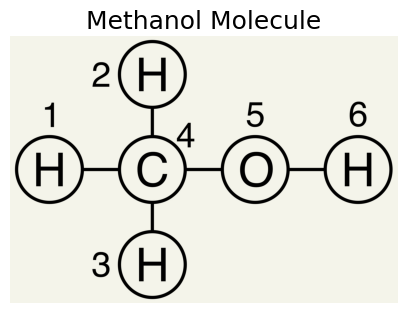

In [4]:
# Download methanol image for visualization
!wget -q https://github.com/qckb/Data-course/blob/main/methanol.jpg?raw=true -O methanol.jpg

# Display the molecule
from PIL import Image
img = Image.open('methanol.jpg')
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Methanol Molecule')
plt.show()

Let's see how a graph can be constructed from a molecule. Consider methanol, shown in the figure.

When representing methanol as a graph:
1. We have 6 nodes (atoms): 1 carbon (C), 1 oxygen (O), and 4 hydrogens (H)
2. We have 5 edges (bonds): 1 C-O, 1 O-H, and 3 C-H bonds


#### Node Features

For each atom (node), we need to define a feature vector. Commonly used atom features include:
- **Atom type** (usually one-hot encoded)
- **Formal charge**
- **Hybridization state**
- **Aromaticity**
- **Number of connected hydrogens**

For simplicity, let's start with just atom type using one-hot encoding:

In [5]:
# Define a simple mapping of atoms to indices
atom_mapping = {'H': 0, 'O': 1, 'C': 2}

# Let's visualize the node feature matrix for methanol
# Atom order:  H, H, H, C, O, H
node_features = np.zeros((6, 3))  # 6 atoms, 3 possible atom types
node_features[0, 0] = 1  # H
node_features[1, 0] = 1  # H
node_features[2, 0] = 1  # H
node_features[3, 2] = 1  # C
node_features[4, 1] = 1  # O
node_features[5, 0] = 1  # H

print("Node Feature Matrix (Rows: Atoms, Columns: Atom Types):")
node_df = pd.DataFrame(node_features,
                      index=['1', '2', '3', '4', '5', '6'],
                      columns=['H', 'O', 'C'])
display(node_df)

Node Feature Matrix (Rows: Atoms, Columns: Atom Types):


,H,O,C
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
5,0.0,1.0,0.0
6,1.0,0.0,0.0


#### Adjacency Matrix

The adjacency matrix represents which atoms are bonded to each other:

In [6]:
# Let's create the adjacency matrix for methanol
# Atom order: H, H, H, C, O, H (indexed from 0 to 5)
adjacency = np.zeros((6, 6))

# Define bonds: C-O, O-H and C-H bonds
bonds = [(0, 3),  # C-H1
         (1, 3),  # C-H2
         (2, 3),  # C-H3
         (3, 4),  # C-O
         (4, 5)]  # O-H4

# Fill the adjacency matrix (undirected graph, so matrix is symmetric)
for i, j in bonds:
    adjacency[i, j] = 1
    adjacency[j, i] = 1  # Symmetric because bonds are undirected

print("Adjacency Matrix (1 indicates a bond between atoms):")
adj_df = pd.DataFrame(adjacency,
                      index=['1', '2', '3', '4', '5', '6'],
                      columns=['1', '2', '3', '4', '5', '6'])
display(adj_df)

Adjacency Matrix (1 indicates a bond between atoms):


,1,2,3,4,5,6
1,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,1.0,1.0,0.0,1.0,0.0
5,0.0,0.0,0.0,1.0,0.0,1.0
6,0.0,0.0,0.0,0.0,1.0,0.0


#### Edge Features

We can also define features for each bond (edge), such as:
- **Bond type** (single, double, triple, aromatic)
- **Bond length**
- **Bond angle**

For simplicity, we'll just use bond type as a feature:

In [7]:
# Create an edge feature tensor for methanol
# We'll use one-hot encoding for bond types: [single, double, triple, aromatic]
num_bonds = len(bonds)
edge_features = np.zeros((num_bonds, 4))  # 5 bonds, 4 possible bond types

# All bonds in methanol are single bonds (index 0)
edge_features[:, 0] = 1

print("Edge Feature Matrix (Rows: Bonds, Columns: Bond Types):")
edge_df = pd.DataFrame(edge_features,
                      index=['C-H1', 'C-H2', 'C-H3', 'C-O', 'O-H4'],
                      columns=['Single', 'Double', 'Triple', 'Aromatic'])
display(edge_df)

Edge Feature Matrix (Rows: Bonds, Columns: Bond Types):


,Single,Double,Triple,Aromatic
C-H1,1.0,0.0,0.0,0.0
C-H2,1.0,0.0,0.0,0.0
C-H3,1.0,0.0,0.0,0.0
C-O,1.0,0.0,0.0,0.0
O-H4,1.0,0.0,0.0,0.0


### Visualizing the Graph Representation

Let's visualize the methanol molecule as a graph:

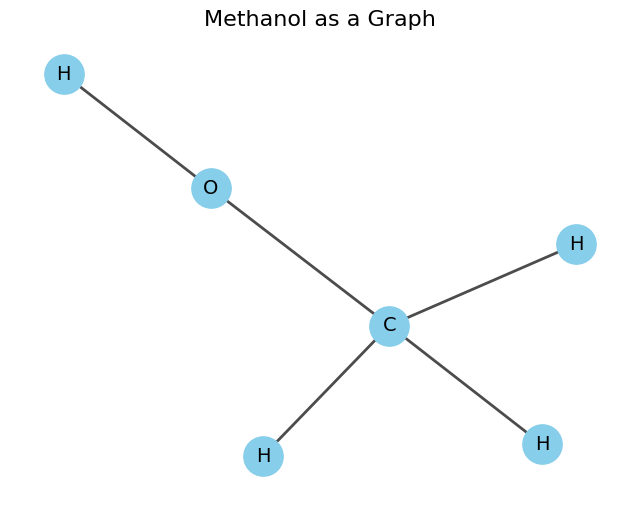

In [8]:
def visualize_molecular_graph(adjacency, node_labels):
    """Visualize a molecule as a graph.

    Args:
        adjacency (numpy.ndarray): Adjacency matrix representing molecular bonds
        node_labels (list): List of atom labels (e.g., ['H', 'C', 'O'])
    """
    # Initialize an empty NetworkX graph
    G = nx.Graph()

    # Add nodes to the graph with their corresponding atom labels
    # Each node represents an atom in the molecule
    for i, label in enumerate(node_labels):
        G.add_node(i, label=label)

    # Extract edges from the adjacency matrix
    # np.where returns indices where adjacency == 1 (indicating a bond)
    rows, cols = np.where(adjacency == 1)
    edges = zip(rows.tolist(), cols.tolist())

    # Add edges to the graph
    # Only add each edge once (i < j) since it's an undirected graph
    for i, j in edges:
        if i < j:  # Add each edge only once
            G.add_edge(i, j)

    # Create a new figure for plotting
    plt.figure(figsize=(8, 6))

    # Calculate node positions using spring layout algorithm
    # seed=42 ensures reproducible layout
    pos = nx.spring_layout(G, seed=42)

    # Draw the nodes as blue circles
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=800)

    # Add atom labels to each node
    nx.draw_networkx_labels(G, pos,
                           labels={i: node_labels[i] for i in range(len(node_labels))},
                           font_size=14)

    # Draw the edges (bonds) between nodes
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.7)

    # Remove axis for cleaner visualization
    plt.axis('off')
    plt.title('Methanol as a Graph', fontsize=16)
    plt.show()

# Define atom labels for methanol molecule (CH3OH)
# Order: 3 hydrogens attached to carbon, carbon, oxygen, hydrogen attached to oxygen
atom_labels = ['H', 'H', 'H', 'C', 'O', 'H']

# Create visualization using the adjacency matrix and atom labels
visualize_molecular_graph(adjacency, atom_labels)

### From Chemical Structure to Graph: The Complete Picture

Now let's put it all together to understand the flow from a chemical structure to a graph representation:

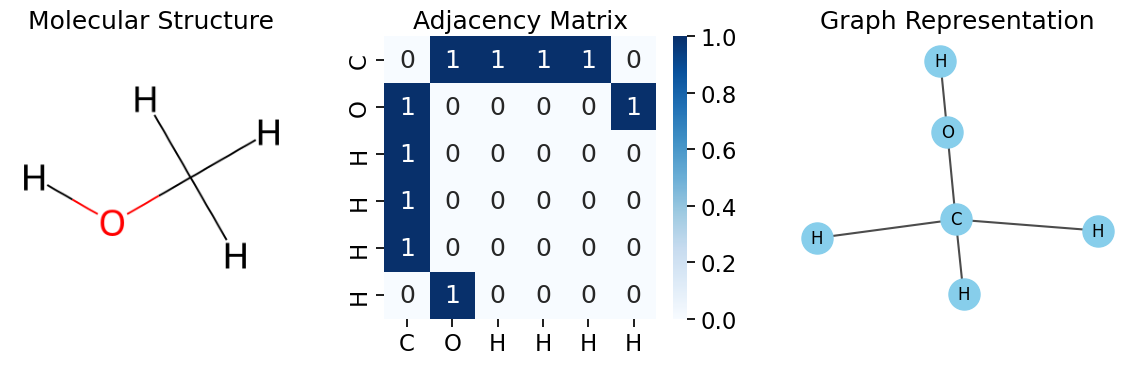

In [ ]:
def show_molecule_to_graph_conversion(smiles: str):
    """
    Show the conversion from molecular structure to graph representation.

    This function takes a SMILES string and creates three visualizations:
    1. The molecular structure (from rdkit)
    2. The adjacency matrix showing atom connections
    3. The graph representation of the molecule

    Args:
        smiles (str): SMILES string representing the molecule

    Returns:
        tuple: (mol, adj_matrix, node_features, atoms)
            - mol: RDKit molecule object
            - adj_matrix: Adjacency matrix showing atom connections
            - node_features: One-hot encoded features for each atom
            - atoms: List of atom symbols in the molecule
    """
    # Step 1: Create RDKit molecule and add hydrogens
    mol = Chem.MolFromSmiles(smiles)  # Convert SMILES to RDKit molecule
    mol = Chem.AddHs(mol)  # Add hydrogens to get complete structure

    # Step 2: Create figure with three subplots
    plt.figure(figsize=(12, 4))

    # Step 3: Draw molecular structure (left subplot)
    plt.subplot(1, 3, 1)
    img = Draw.MolToImage(mol, size=(300, 300))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Molecular Structure')

    # Step 4: Extract atom information
    atoms = [a.GetSymbol() for a in mol.GetAtoms()]  # Get atom symbols

    # Step 5: Create adjacency matrix
    n_atoms = len(atoms)
    adj_matrix = np.zeros((n_atoms, n_atoms))  # Initialize with zeros

    # Fill adjacency matrix based on bonds
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()  # Get start atom index
        j = bond.GetEndAtomIdx()    # Get end atom index
        adj_matrix[i, j] = 1        # Mark connection in both directions
        adj_matrix[j, i] = 1        # (since bonds are undirected)

    # Step 6: Create node features using one-hot encoding
    unique_atoms = sorted(set(atoms))  # Get unique atom types
    atom_to_idx = {atom: i for i, atom in enumerate(unique_atoms)}  # Map atoms to indices

    # Initialize node features matrix
    node_features = np.zeros((n_atoms, len(unique_atoms)))
    # Fill node features matrix
    for i, atom in enumerate(atoms):
        node_features[i, atom_to_idx[atom]] = 1  # Set 1 for corresponding atom type

    # Step 7: Visualize adjacency matrix (middle subplot)
    plt.subplot(1, 3, 2)
    sns.heatmap(adj_matrix, cmap='Blues', annot=True, fmt='.0f',
                xticklabels=atoms, yticklabels=atoms)
    plt.title('Adjacency Matrix')

    # Step 8: Create and visualize graph (right subplot)
    plt.subplot(1, 3, 3)
    G = nx.Graph()  # Create empty graph

    # Add nodes with atom labels
    for i, atom in enumerate(atoms):
        G.add_node(i, label=atom)

    # Add edges based on adjacency matrix
    rows, cols = np.where(adj_matrix == 1)  # Get indices of connections
    edges = zip(rows.tolist(), cols.tolist())
    for i, j in edges:
        if i < j:  # Add each edge only once (avoid duplicates)
            G.add_edge(i, j)

    # Plot the graph with custom styling
    pos = nx.spring_layout(G, seed=42)  # Calculate node positions
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)  # Draw nodes
    nx.draw_networkx_labels(G, pos, labels={i: atoms[i] for i in range(len(atoms))},
                           font_size=12)  # Add atom labels
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)  # Draw edges
    plt.axis('off')
    plt.title('Graph Representation')

    # Finalize plot
    plt.tight_layout()
    plt.show()

    return mol, adj_matrix, node_features, atoms

# Demonstrate the function with methanol (CH3OH)
methanol_smiles = "CO"
mol, adj_matrix, node_features, atoms = show_molecule_to_graph_conversion(methanol_smiles)

### ✅ Checkpoint: Understanding Molecular Graphs

To reinforce your understanding, try answering these questions:

1. **Question**: What does each row in the node feature matrix represent?
   - **Answer**: Each row represents one atom in the molecule, with its features encoded.

2. **Question**: Why is the adjacency matrix symmetric for molecules?
   - **Answer**: Because chemical bonds are undirected (atoms are mutually bonded to each other).

3. **Question**: How would the graph representation change for a molecule with a double bond?
   - **Answer**: The edge feature for that bond would have a 1 in the position representing double bonds instead of single bonds.